In [ ]:
import os
from typing import List
from pydantic import BaseModel
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain_ollama import OllamaEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END
from langfuse.langchain import CallbackHandler
from dotenv import load_dotenv

load_dotenv()

langfuse_trace = CallbackHandler()


d:\ai_learning\krisknaik\ultimate-rag-bootcamp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Tho Le\AppData\Local\Temp\ipykernel_8024\2983474735.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


In [ ]:
# -------------------------------
# 1. Prepare Vectorstore
# -------------------------------
docs = TextLoader("research_notes.txt",encoding="utf-8").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)
# embedding = OpenAIEmbeddings()
embedding = OllamaEmbeddings()
vectorstore = FAISS.from_documents(chunks, embedding)
retriever = vectorstore.as_retriever()

In [3]:
from langchain.chat_models import init_chat_model

ollama_llm = init_chat_model(
    model="granite4",
    model_provider="ollama"
)

openai_llm = init_chat_model(
    model="gpt-4.1-nano",
    model_provider="openai"
)

In [4]:
# -------------------------------
# 2. LangGraph State Definition
# -------------------------------
class RAGCoTState(BaseModel):
    question: str
    sub_steps: List[str] = []
    retrieved_docs: List[Document] = []
    answer: str = ""

In [5]:
# -------------------------------
# 3. Nodes
# -------------------------------

# a. Plan sub-questions
def plan_steps(state: RAGCoTState) -> RAGCoTState:
    prompt = f"Break the question into 2-3 reasoning steps: \n\n {state.question}"
    result = ollama_llm.invoke(
        prompt,
        config={"callbacks": [langfuse_trace]}
    ).content
    subqs=[line.strip("- ") for line in result.split("\n") if line.strip()]

    return state.model_copy(update={
        "sub_steps": subqs
    })

In [6]:
# b. Retrieve for each step
def retrieve_per_step(state: RAGCoTState) -> RAGCoTState:
    all_docs = []
    for sub in state.sub_steps:
        docs = retriever.invoke(
            sub,
            config={"callbacks": [langfuse_trace]}
        )
        all_docs.extend(docs)
    return state.model_copy(
        update={
            "retrieved_docs": all_docs
        }
    )

In [7]:
# c. Generate Final Answer
def generate_answer(state: RAGCoTState) -> RAGCoTState:
    
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""
You are answering a complex question using reasoning and retrieved documents.

Question: {state.question}

Relevant Information:
{context}

Now synthesize a well-reasoned final answer.
"""
    result = ollama_llm.invoke(
        prompt,
        config={"callbacks": [langfuse_trace]}
    ).content.strip()
    return state.model_copy(update={"answer": result})

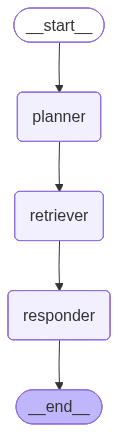

In [8]:
# -------------------------------
# 4. LangGraph Graph
# -------------------------------

builder = StateGraph(RAGCoTState)
# Add nodes
builder.add_node("planner", plan_steps)
builder.add_node("retriever", retrieve_per_step)
builder.add_node("responder", generate_answer)

builder.set_entry_point("planner")
# Add edges
builder.add_edge("planner", "retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", END)

graph = builder.compile()
graph

In [9]:
# -------------------------------
# 5. Run CoT RAG Agent
# -------------------------------
if __name__ == "__main__":
    query = "what are the additional eperiments in Transformer eveluation?"
    state = RAGCoTState(question=query)
    final = graph.invoke(state, config={"callbacks": [langfuse_trace]})

    print("\n🪜 Reasoning Steps:", final["sub_steps"])
    print("\n✅ Final Answer:\n", final["answer"])


🪜 Reasoning Steps: ['Breaking down the question "What are the additional experiments in Transformer evaluation?" into 2-3 reasoning steps:', 'Step 1: Identify the main topic', 'The main topic of the question is related to evaluating Transformers, which are a type of neural network architecture commonly used for natural language processing (NLP) tasks.', 'Step 2: Understand the context and purpose', 'Transformer models have gained significant popularity in recent years due to their effectiveness in various NLP applications. The evaluation experiments aim to assess the performance, capabilities, and limitations of these models on specific tasks or datasets.', 'Step 3: Determine the key aspects of additional experiments', 'The question is asking about additional experiments that can be conducted during Transformer evaluation. These experiments may focus on different aspects such as:', 'Adversarial testing to evaluate the robustness of Transformers against adversarial attacks.', "Cross-li